In [41]:
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.model_selection import GridSearchCV

In [42]:
df = pd.read_csv('stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [43]:
x = df.drop('math_score', axis=1)
y = df['math_score']

In [44]:
x

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [45]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [46]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

cat_cols = x.select_dtypes(include='object').columns
num_cols = x.select_dtypes(exclude='object').columns

ct = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(), cat_cols),
    ('scaling', StandardScaler(), num_cols)
])

x = ct.fit_transform(x)

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)
x_train

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.05694554,  0.45733301],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.94779033,  0.98406266],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.35894946,  1.18158627],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -0.49126664, -0.99117351],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        -1.45063795, -0.99117351],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.4960025 ,  1.37910989]], shape=(800, 19))

1. from sklearn.linear_model import LinearRegression,Lasso,Ridge
2. from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
3. from sklearn.tree import DecisionTreeRegressor
4. from sklearn.neighbors import KNeighborsRegressor
5. from sklearn.svm import SVR
6. from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
7. from sklearn.model_selection import GridSearchCV

In [48]:
models ={
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'SVR': SVR(),
    'RandomForestRegressor': RandomForestRegressor(),
    'AdaBoostRegressor': AdaBoostRegressor()
}

In [52]:
for name,model in models.items():
    model.fit(x_train,y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    print(f'{name} : ')
    print('==============================')
    print('train set evaluation :')
    print(f'Mean Absolute Error: {mean_absolute_error(y_train, y_train_pred)}')
    print(f'Mean Squared Error: {mean_squared_error(y_train, y_train_pred)}')
    print(f'R2 Score: {r2_score(y_train, y_train_pred)}')
    print('-----------------------------')
    print('test set evaluation :')
    print(f'Mean Absolute Error: {mean_absolute_error(y_test, y_test_pred)}')
    print(f'Mean Squared Error: {mean_squared_error(y_test, y_test_pred)}')
    print(f'R2 Score: {r2_score(y_test, y_test_pred)}')
    print('==============================')



LinearRegression : 
train set evaluation :
Mean Absolute Error: 4.266711846071957
Mean Squared Error: 28.33487038064859
R2 Score: 0.8743172040139593
-----------------------------
test set evaluation :
Mean Absolute Error: 4.214763142474852
Mean Squared Error: 29.095169866715516
R2 Score: 0.8804332983749564
Lasso : 
train set evaluation :
Mean Absolute Error: 5.206302661246526
Mean Squared Error: 43.47840400585578
R2 Score: 0.8071462015863458
-----------------------------
test set evaluation :
Mean Absolute Error: 5.157881810347763
Mean Squared Error: 42.506416838411624
R2 Score: 0.8253197323627852
Ridge : 
train set evaluation :
Mean Absolute Error: 4.264987823725981
Mean Squared Error: 28.33778823308244
R2 Score: 0.8743042615212909
-----------------------------
test set evaluation :
Mean Absolute Error: 4.21110068801426
Mean Squared Error: 29.05627219234829
R2 Score: 0.8805931485028738
DecisionTreeRegressor : 
train set evaluation :
Mean Absolute Error: 0.01875
Mean Squared Error: 0.0

In [54]:
from sklearn.linear_model import Ridge
model = Ridge()
model.fit(x_train,y_train)
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
print(f"r2 score of Ridge Regression:{r2_score(y_test, y_test_pred)}")
print(f"mean absolute error of Ridge Regression:{mean_absolute_error(y_test, y_test_pred)}")
print(f"mean squared error of Ridge Regression:{mean_squared_error(y_test, y_test_pred)}")

r2 score of Ridge Regression:0.8805931485028738
mean absolute error of Ridge Regression:4.21110068801426
mean squared error of Ridge Regression:29.05627219234829


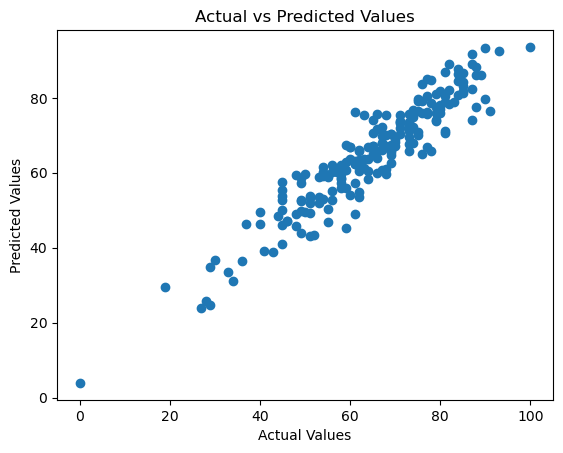

In [55]:
plt.scatter(y_test, y_test_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

<Axes: xlabel='math_score'>

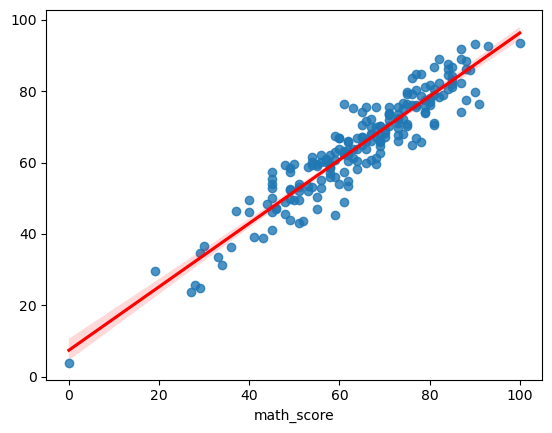

In [56]:
import seaborn as sns
sns.regplot(x=y_test, y=y_test_pred, line_kws={"color": "red"})

In [58]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred,"difference": y_test - y_test_pred})

,Actual,Predicted,difference
521,91,76.398705,14.601295
737,53,58.842469,-5.842469
740,80,76.992129,3.007871
660,74,76.805898,-2.805898
411,84,87.615387,-3.615387
...,...,...,...
408,52,43.492293,8.507707
332,62,62.170763,-0.170763
208,74,67.910325,6.089675
613,65,67.061504,-2.061504
